In [1]:
#Necesaary Libraries are imported...
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import seaborn as sns
from ydata_profiling import ProfileReport
warnings.filterwarnings("ignore")


In [2]:
#Loading Data...
sales=pd.read_csv("sales_data.csv",parse_dates=["Order_Date"])
marketing=pd.read_csv("marketing_data.csv",parse_dates=["Start_Date","End_Date"])
products=pd.read_csv("product_data.csv")
customers=pd.read_csv("customer_data.csv")
print(sales.to_string())

      Order_ID Order_Date  Product_ID Region  Quantity  Revenue  Cost  Channel  Profit
0            1 2024-05-10          37   West         4     4103  3364   Online     739
1            2 2024-12-31          43  North         5     4413  6746   Online   -2333
2            3 2024-11-10          39   West         4     1919  5663   Online   -3744
3            4 2022-05-02          42  South         4     2667  6103   Online   -3436
4            5 2023-04-12          17   West         9     2644  1530   Online    1114
5            6 2022-11-27          15  North         2     2667  7842  Offline   -5175
6            7 2022-03-29          18   East         6     9868  6726   Online    3142
7            8 2024-05-21          23  North         8     9960  6921   Online    3039
8            9 2022-05-11          30   West         8     6391  5441   Online     950
9           10 2024-02-09          34   West         7     7036   858   Online    6178
10          11 2022-12-10           4   Eas

EDA performed on sales dataset

In [3]:
ProfileReport(sales)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 101.82it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
#products dataset is loaded
products.head()

,Product_ID,Product_Name,Category,Base_Price
0,1,Product_1,Home,5283
1,2,Product_2,Grocery,1519
2,3,Product_3,Home,9987
3,4,Product_4,Clothing,8098
4,5,Product_5,Electronics,1549


In [5]:
#performing EDA on products dataset
ProfileReport(products)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 287.78it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
marketing.head()

,Campaign_ID,Channel,Spend,Revenue_Attributed,Start_Date,End_Date
0,1,Social Media,173315,311328,2023-05-12,2023-06-17
1,2,Email,65915,36902,2023-01-09,2023-02-27
2,3,Social Media,227041,312791,2023-08-19,2023-08-24
3,4,Email,299523,210446,2023-06-02,2023-06-17
4,5,Ads,99146,59140,2023-11-01,2023-12-01


In [7]:
#Performing EDA on marketing Dataset
ProfileReport(marketing)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 185.91it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
customers.head()

,Customer_ID,Age_Group,Gender,Region,Customer_Type
0,1,36-45,Female,South,Repeat
1,2,18-25,Female,South,New
2,3,46-60,Male,North,New
3,4,26-35,Female,West,New
4,5,26-35,Male,West,New


In [9]:
ProfileReport(customers)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 79.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
#Profit calculation...
sales.columns

Index(['Order_ID', 'Order_Date', 'Product_ID', 'Region', 'Quantity', 'Revenue',
       'Cost', 'Channel', 'Profit'],
      dtype='object')

In [11]:
sales["Profit"]=sales["Revenue"]-sales["Cost"]
sales[["Profit"]]

,Profit
0,739
1,-2333
2,-3744
3,-3436
4,1114
...,...
4995,3155
4996,3517
4997,-5091
4998,-4909


In [12]:
#Extracting year and month columns
sales["Year"]= sales["Order_Date"].dt.year
sales["Month"]= sales["Order_Date"].dt.month

In [13]:
sales[["Year"]].head()

,Year
0,2024
1,2024
2,2024
3,2022
4,2023


In [14]:
sales[["Month"]].head()

,Month
0,5
1,12
2,11
3,5
4,4


In [15]:
# Merging Data
sales_merged = sales.merge(products,on="Product_ID", how="left")

In [16]:
sales_merged

,Order_ID,Order_Date,Product_ID,Region,Quantity,Revenue,Cost,Channel,Profit,Year,Month,Product_Name,Category,Base_Price
0,1,2024-05-10,37,West,4,4103,3364,Online,739,2024,5,Product_37,Clothing,12905
1,2,2024-12-31,43,North,5,4413,6746,Online,-2333,2024,12,Product_43,Home,13698
2,3,2024-11-10,39,West,4,1919,5663,Online,-3744,2024,11,Product_39,Grocery,4610
3,4,2022-05-02,42,South,4,2667,6103,Online,-3436,2022,5,Product_42,Electronics,14830
4,5,2023-04-12,17,West,9,2644,1530,Online,1114,2023,4,Product_17,Clothing,1205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2022-01-13,3,West,7,7639,4484,Online,3155,2022,1,Product_3,Home,9987
4996,4997,2024-11-07,1,East,8,7204,3687,Online,3517,2024,11,Product_1,Home,5283
4997,4998,2023-11-25,50,East,1,2387,7478,Offline,-5091,2023,11,Product_50,Home,12144
4998,4999,2024-08-30,27,East,5,559,5468,Offline,-4909,2024,8,Product_27,Electronics,13985


KPI calculations

In [17]:
total_revenue=sales["Revenue"].sum()
total_profit=sales["Profit"].sum()
total_sales=sales["Quantity"].sum()
profit_margin=(total_profit/total_revenue)*100
print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Sales:",  total_sales)
print("Profit Margin:", round(profit_margin,2))

Total Revenue: 26335346
Total Profit: 5540416
Total Sales: 24840
Profit Margin: 21.04


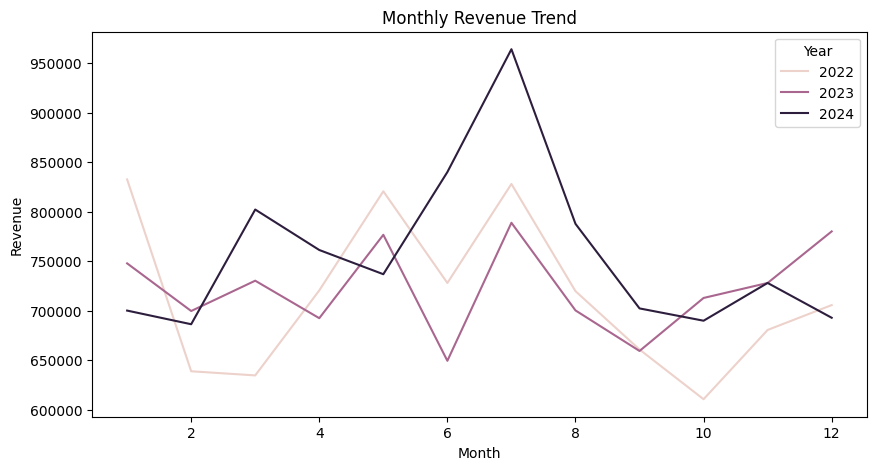

In [28]:
#Sales Trend Analysis

monthly_sales=sales.groupby(["Year","Month"])["Revenue"].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x="Month",y="Revenue", hue="Year")
plt.title("Monthly Revenue Trend")
plt.show()

In [31]:
# Regional Performance..
region_perf=sales.groupby("Region").agg(Revenue=("Revenue","sum"),Profit=("Profit","sum")).reset_index()

In [32]:
region_perf

,Region,Revenue,Profit
0,East,6324574,1288872
1,North,6704160,1466647
2,South,6316759,1247068
3,West,6989853,1537829


In [67]:
#Product Perfromance..
product_perf=sales_merged.groupby("Product_Name")[["Revenue","Profit"]].sum().reset_index()

In [73]:
product_perf.head()

,Product_Name,Revenue,Profit
0,Product_1,529785,127845
1,Product_10,557290,118196
2,Product_11,516888,114604
3,Product_12,593604,133675
4,Product_13,643323,130147


In [86]:
product_perf["Profit_margin"]=round((product_perf["Profit"]/product_perf["Revenue"])*100,2)

In [87]:
product_perf[["Profit_margin"]].head()

,Profit_margin
0,24.13
1,21.21
2,22.17
3,22.52
4,20.23


In [91]:
#Top and Bottom Products..
top_products=product_perf.sort_values("Profit_margin",ascending=False)
top_products.head()

,Product_Name,Revenue,Profit,Profit_margin
21,Product_29,536328,200319,37.35
10,Product_19,560681,186243,33.22
16,Product_24,582600,184025,31.59
12,Product_20,482727,148114,30.68
45,Product_50,561249,169806,30.26


In [95]:
bottom_products=product_perf.sort_values("Profit_margin").head()

In [96]:
bottom_products

,Product_Name,Revenue,Profit,Profit_margin
38,Product_44,458193,25040,5.46
31,Product_38,503629,50707,10.07
43,Product_49,518553,53417,10.30
46,Product_6,456114,48946,10.73
7,Product_16,589883,73394,12.44


In [114]:
print("Top_products:\n",top_products.head())
print("Bottom_products:\n",bottom_products)

Top_products:
    Product_Name  Revenue  Profit  Profit_margin
21   Product_29   536328  200319          37.35
10   Product_19   560681  186243          33.22
16   Product_24   582600  184025          31.59
12   Product_20   482727  148114          30.68
45   Product_50   561249  169806          30.26
Bottom_products:
    Product_Name  Revenue  Profit  Profit_margin
38   Product_44   458193   25040           5.46
31   Product_38   503629   50707          10.07
43   Product_49   518553   53417          10.30
46    Product_6   456114   48946          10.73
7    Product_16   589883   73394          12.44


In [115]:
#Customer behavior Analysis..
Customer_sales=sales.merge(customers,on="Region",how="left")

In [119]:
Customer_sales.head()

,Order_ID,Order_Date,Product_ID,Region,Quantity,Revenue,Cost,Channel,Profit,Year,Month,Customer_ID,Age_Group,Gender,Customer_Type
0,1,2024-05-10,37,West,4,4103,3364,Online,739,2024,5,4,26-35,Female,New
1,1,2024-05-10,37,West,4,4103,3364,Online,739,2024,5,5,26-35,Male,New
2,1,2024-05-10,37,West,4,4103,3364,Online,739,2024,5,11,36-45,Male,Repeat
3,1,2024-05-10,37,West,4,4103,3364,Online,739,2024,5,20,46-60,Male,Repeat
4,1,2024-05-10,37,West,4,4103,3364,Online,739,2024,5,21,26-35,Female,Repeat


In [120]:
customer_type_perf=Customer_sales.groupby("Customer_Type")[["Revenue","Profit"]].sum().reset_index()

In [121]:
customer_type_perf

,Customer_Type,Revenue,Profit
0,New,5117619926,1077526204
1,Repeat,8047701109,1691631450


In [132]:
marketing.columns

Index(['Campaign_ID', 'Channel', 'Spend', 'Revenue_Attributed', 'Start_Date',
       'End_Date'],
      dtype='object')

In [135]:
#Marketing ROI Analysis..

marketing["ROI"]=round(((marketing["Revenue_Attributed"]-marketing["Spend"])/marketing["Spend"])*100,2)

In [138]:
marketing[["ROI"]].head()

,ROI
0,79.63
1,-44.02
2,37.77
3,-29.74
4,-40.35


In [182]:
channel_roi=marketing.groupby("Channel").agg(Avg_ROI=("ROI","mean"),Total_Spend=("Spend","sum")).reset_index()

In [184]:
channel_roi

,Channel,Avg_ROI,Total_Spend
0,Ads,187.903836,10861146
1,Email,138.419697,10133300
2,Social Media,179.912951,9545653


In [185]:
#from scipy.stats import ttest_ind
#north_rev=sales[sales["Region"]=="North"]["Revenue"]
#south_rev=sales[sales["Region"]=="South"]["Revenue"]
#t_stat, p_value = ttest_ind(north_rev, south_rev, equal_var=False)
#print("T-statistic:", t_stat)
#print("P-valu:", p_value)

In [186]:
region_perf["Profit_margins"]=round((region_perf["Profit"]/region_perf["Revenue"])*100,2)
region_perf

,Region,Revenue,Profit,Profit_margins
0,East,6324574,1288872,20.38
1,North,6704160,1466647,21.88
2,South,6316759,1247068,19.74
3,West,6989853,1537829,22.00


In [187]:
#Business Insights..
#Low Margin regions
low_margin_region = region_perf[region_perf["Profit_margins"]<profit_margin]
low_margin_region

,Region,Revenue,Profit,Profit_margins
0,East,6324574,1288872,20.38
2,South,6316759,1247068,19.74


In [188]:
high_roi_channels = channel_roi[channel_roi["Avg_ROI"]>100]
print("High ROI Channels:\n", high_roi_channels)

High ROI Channels:
         Channel     Avg_ROI  Total_Spend
0           Ads  187.903836     10861146
1         Email  138.419697     10133300
2  Social Media  179.912951      9545653
